# Aprendizaje supervisado

El aprendizaje supervisado es un tipo de aprendizaje automático en el que un algoritmo aprende de un conjunto de datos etiquetados para predecir resultados o clasificar datos

## Pasos a seguir:
1. Crear conjunto de datos de entrenamiento y prueba:
Se proporciona al algoritmo un conjunto de datos de entrenamiento (X_Train) junto con las etiquetas correspondientes (y_train).
2. Selección del modelo:
Escoge el modelo apropiado dependiendo del conjunto de datos y el problema a solucionar.
3. Entrenar el modelo:
El algoritmo analiza los datos y ajusta sus parámetros internos para aprender la relación entre las características de entrada y las etiquetas.
4. Predicción:
Una vez entrenado, usar el conjunto de datos de prueba (X_test)
y predecir la salida, basándose en lo aprendido (y_pred)
5. Evaluar el modelo:
Comparar estas predicciones con las etiquetas correspondientes del conjunto de prueba (y_pred vs y_test)
---



## 1. Clasificación
La clasificación es un tipo de aprendizaje supervisado donde el objetivo es predecir una etiqueta o categoría para una nueva observación basándose en datos previos.

- Ejemplos cotidianos:

  - Clasificación de correos electrónicos como spam o no spam.
  - Diagnóstico médico basado en análisis clínicos.
  - Predicción de aprobación o rechazo de un crédito bancario.

### 1.1. Tipos de Clasificación

- Binaria: Dos clases posibles (ejemplo: spam o no spam).

- Multiclase: Múltiples clases sin superposición (ejemplo: clasificación de marcas de automóviles).

- Multietiqueta: Cada observación puede pertenecer a varias clases al mismo tiempo (ejemplo: categoría de géneros de películas en una plataforma de streaming).

---
### Librerias a usar:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# 2. Carga y exploración de datos
https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset

In [ ]:
from sklearn.datasets import load_wine

data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Primera vista del dataset:")
display(df.head())
print("\nInformación del dataset:")
df.info()
print("\nDistribución de la variable objetivo:")
print(df['target'].value_counts())


Primera vista del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-

- Visualización básica de la distribución de las clases del dataset

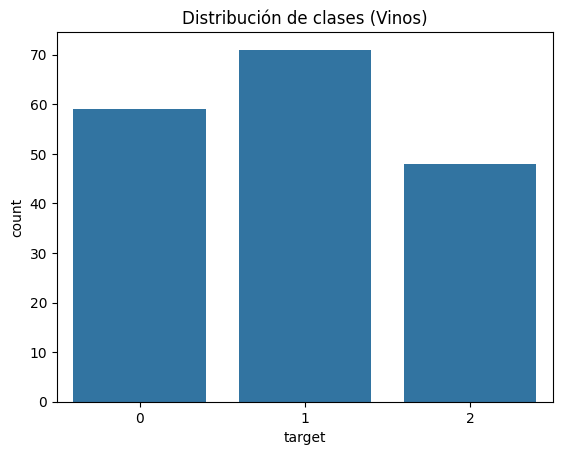

In [ ]:
sns.countplot(x='target', data=df)
plt.title('Distribución de clases (Vinos)')
plt.show()

# 3. Preprocesamiento

In [ ]:
# X: Conjunto de caracteristicas
# y: Variable Objetivo
X = df.drop('target', axis=1)
y = df['target']

# División en conjuntos de entrenamiento y prueba (usa stratify para respetar proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Escalado (muy importante para algunos modelos como KNN y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Pregunta: ¿Por qué normalizamos los datos?

In [ ]:
X_train.shape, X_test.shape

((142, 13), (36, 13))

# 4. Entrenamiento de modelos

## 4.1. Modelos de Clasificación

A continuación, se presentan algunos de los modelos de clasificación más utilizados:

### 4.1.1 Regresión Logística

Modelo estadístico que estima la probabilidad de pertenencia a una clase.

- Ventaja: Simple y rápido de entrenar.
- Ejemplo de uso: Predicción de fraude en transacciones bancarias.
- Referencias: https://www.youtube.com/watch?v=EKm0spFxFG4

### 4.1.2 K-Nearest Neighbors (KNN)

Clasifica un punto basándose en la mayoría de sus vecinos más cercanos.

- Ventaja: Intuitivo y sin suposiciones sobre los datos.
- Ejemplo de uso: Clasificación de apps móviles en categorías según su uso.
- Referencias: https://www.youtube.com/watch?v=0p0o5cmgLdE

### 4.1.3 Árboles de Decisión

Modelo basado en reglas de decisiones para realizar la clasificación.

- Ventaja: Fácil de interpretar.
- Ejemplo de uso: Aprobar o rechazar créditos bancarios.
- Referencias:
  - https://www.youtube.com/watch?v=JcI5E2Ng6r4&t
  - https://www.youtube.com/watch?v=32-eBE9-4zc&t

### 4.1.4 Random Forest

Conjunto de múltiples árboles de decisión que mejoran la precisión.

- Ventaja: Reduce el sobreajuste.
- Ejemplo de uso: Clasificación de clientes para ofertas personalizadas.
- Referencias: https://www.youtube.com/watch?v=VfMPslt2wgA

### 4.1.5 Support Vector Machines (SVM)

Encuentra el hiperplano óptimo para separar las clases.

- Ventaja: Funciona bien en datos no lineales.
- Ejemplo de uso: Clasificación de tipos de automóviles según características.
- Referencias:
 - https://www.youtube.com/watch?v=jo9slrXKKNo
 - https://www.youtube.com/watch?v=_YPScrckx28

### 4.1.6. Naive Bayes

Basado en la teoría de probabilidad de Bayes, asume independencia entre variables.

 - Ventaja: Eficiente con grandes volúmenes de datos.
 - Ejemplo de uso: Clasificación de opiniones en reseñas de productos (positiva/negativa).
 - Referencias:
   - https://www.youtube.com/watch?v=oQ1OyqvL7dQ
   - https://youtu.be/O2L2Uv9pdDA?t=68

### Tabla Comparativa de Modelos
| Modelo | Cómo Funciona | Casos de Uso |
|--------|---------------|--------------|
| **Regresión Logística** | Calcula probabilidad usando función sigmoide | Clasificación lineal - clasificación binaria, buen baseline |
| **K-Vecinos Más Cercanos (KNN)** | Busca vecinos más similares en el espacio de características | Datos pequeños, relaciones complejas no lineales |
| **Árboles de Decisión** | Divide datos con reglas jerárquicas | Datos interpretables, relaciones no lineales |
| **Random Forest** | Combina múltiples árboles (ensamble) | Datos complejos, alto rendimiento general |
| **SVM (Máquinas de Vectores Soporte)** | Encuentra hiperplano óptimo entre clases | Datos de alta dimensión, márgenes claros |
| **Naive Bayes** | Usa probabilidad bayesiana con supuesto de independencia | Text mining, datos con muchas features |

## 4.2 Ejemplos Prácticos

In [ ]:
BosqueAleatorio = RandomForestClassifier()
BosqueAleatorio

RandomForestClassifier()

In [ ]:
BosqueAleatorio.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = BosqueAleatorio.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



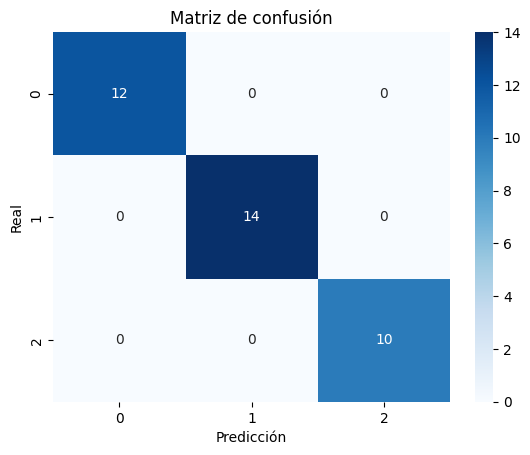

In [ ]:
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression - Accuracy: 0.9722 | F1 Macro: 0.9710
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



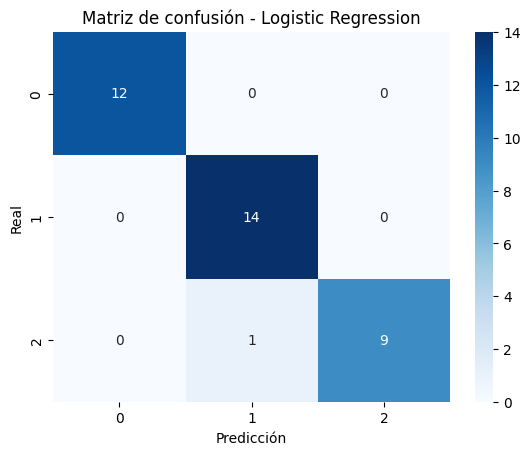


KNN - Accuracy: 0.9722 | F1 Macro: 0.9718
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



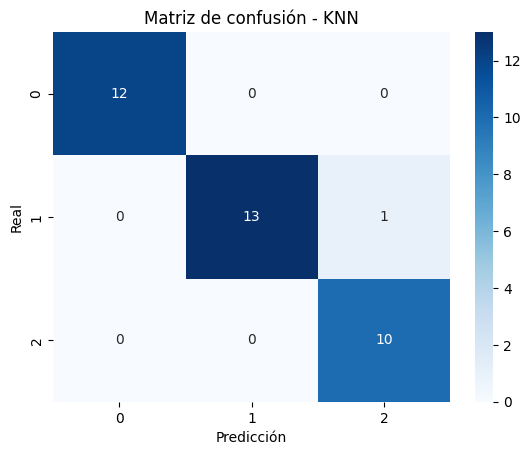


Decision Tree - Accuracy: 0.9444 | F1 Macro: 0.9457
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



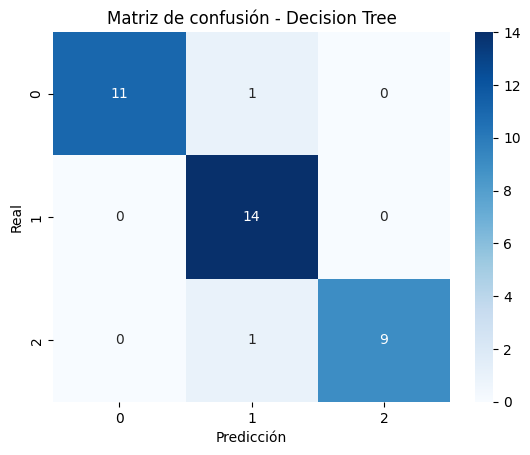


Random Forest - Accuracy: 1.0000 | F1 Macro: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



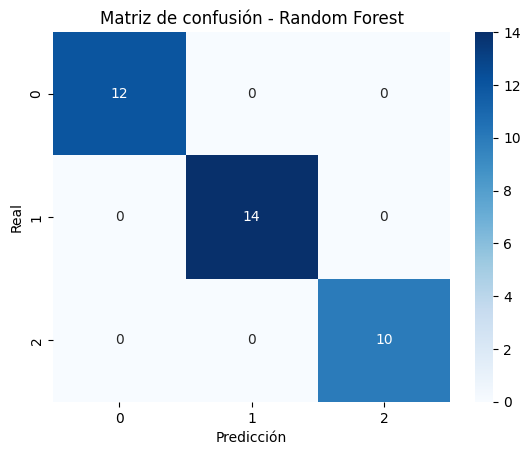


SVC (Linear) - Accuracy: 0.9444 | F1 Macro: 0.9453
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



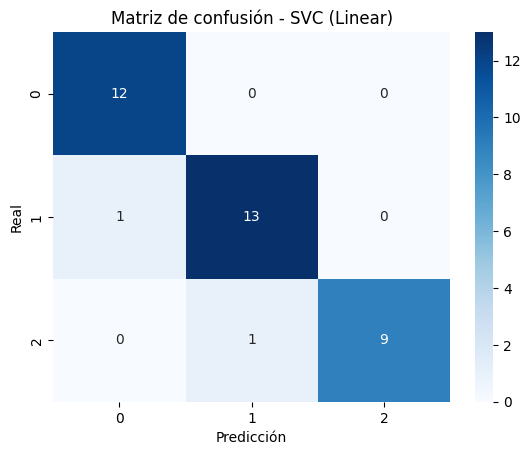


GaussianNB - Accuracy: 0.9722 | F1 Macro: 0.9743
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



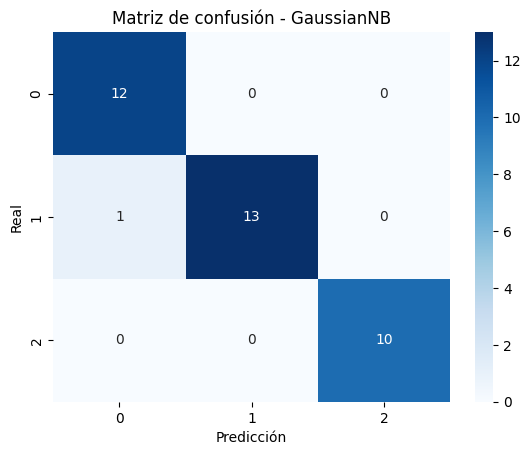

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs'),
    "KNN": KNeighborsClassifier(), ## K = Raiz cuadradada de N
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "GaussianNB": GaussianNB()
}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # ENTRENAR
    y_pred = model.predict(X_test_scaled) # PREDICCION
    # EVALUAR MODELO
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "y_pred": y_pred
    }
    print(f"\n{name} - Accuracy: {acc:.4f} | F1 Macro: {f1_macro:.4f}")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# 5. Comparación visual de modelos

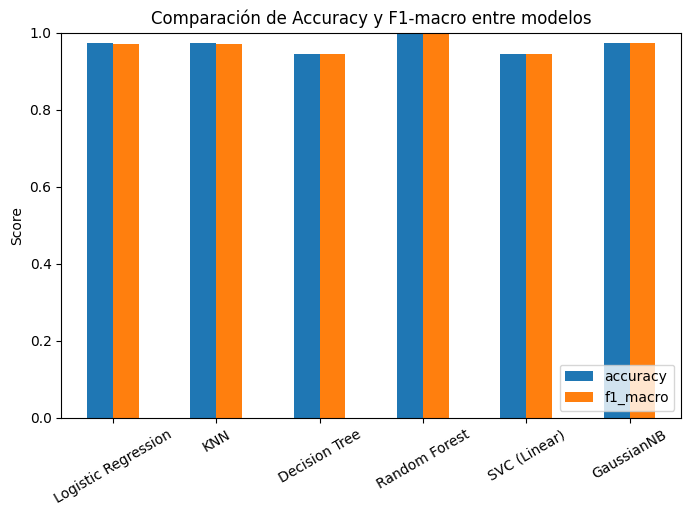

In [ ]:
metricas = pd.DataFrame({
    'accuracy': {name: res['accuracy'] for name, res in results.items()},
    'f1_macro': {name: res['f1_macro'] for name, res in results.items()}
})

metricas.plot(kind='bar', figsize=(8,5))
plt.title('Comparación de Accuracy y F1-macro entre modelos')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.show()

# ¿Por qué es útil comparar F1-macro además de accuracy?

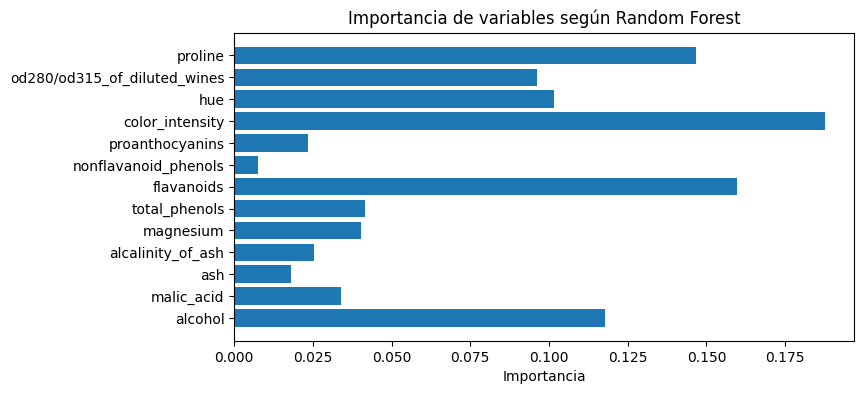

In [ ]:
# Importancia de características para Random Forest
importancias = results['Random Forest']['model'].feature_importances_
plt.figure(figsize=(8,4))
plt.barh(df.columns[:-1], importancias)
plt.title('Importancia de variables según Random Forest')
plt.xlabel('Importancia')
plt.show()

# 6. Tuning de hiperparámetros

In [ ]:
modelos_para_tuning = {
    "Logistic Regression": (LogisticRegression(max_iter=200, solver='lbfgs'),
                            {'C':[0.01, 0.1, 1, 10]}),
    "KNN": (KNeighborsClassifier(), {'n_neighbors':[3,5,7,9]}),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), {'max_depth':[2,4,6,8,10]}),
    "Random Forest": (RandomForestClassifier(random_state=42), {'n_estimators':[50,100], 'max_depth':[2,4,6]}),
    "SVC (Linear)": (SVC(kernel='linear', probability=True, random_state=42), {'C':[0.1,1,10]})
}

mejores_modelos = {}

for name, (modelo, params) in modelos_para_tuning.items():
    print(f"\nBuscando mejores hiperparámetros para {name}...")
    grid = GridSearchCV(modelo, params, cv=4, scoring='f1_macro')
    grid.fit(X_train_scaled, y_train)
    print("Mejores parámetros:", grid.best_params_)
    mejor_modelo = grid.best_estimator_
    y_pred = mejor_modelo.predict(X_test_scaled)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    print(f"F1-macro en test: {f1_macro:.4f}")
    mejores_modelos[name] = {
        'model': mejor_modelo,
        'f1_macro': f1_macro,
        'params': grid.best_params_
    }


Buscando mejores hiperparámetros para Logistic Regression...
Mejores parámetros: {'C': 0.1}
F1-macro en test: 1.0000

Buscando mejores hiperparámetros para KNN...
Mejores parámetros: {'n_neighbors': 9}
F1-macro en test: 1.0000

Buscando mejores hiperparámetros para Decision Tree...
Mejores parámetros: {'max_depth': 4}
F1-macro en test: 0.9457

Buscando mejores hiperparámetros para Random Forest...
Mejores parámetros: {'max_depth': 2, 'n_estimators': 50}
F1-macro en test: 0.9743

Buscando mejores hiperparámetros para SVC (Linear)...
Mejores parámetros: {'C': 0.1}
F1-macro en test: 0.9710
